# Measuring an interaction matrix

An interaction matrix describes the response of a wavefront sensor to
small perturbations applied to the deformable mirror.

For each DM mode we perform a push-pull measurement:

\[
M_i =
\frac{
    s(+\epsilon_i) - s(-\epsilon_i)
}{
    2\epsilon
}.
\]

We then compute a control matrix from the measured responses.

In [1]:
import torch
import matplotlib.pyplot as plt

from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import Band, Spectrum
from fiatlux.core.source import PlaneWave
from fiatlux.optics.elements.mask import CircularAperture
from fiatlux.optics.elements.deformable_mirror import (
    ActuatorGrid,
    DeformableMirror,
    ZernikeBasis,
)
from fiatlux.optics.propagator import MFTPropagator
from fiatlux.optics.detector import Detector
from fiatlux.system.optical_system import SerialSystem
from fiatlux.system.interaction_matrix import InteractionMatrix

In [2]:
D = 1.0
wavelength = 1.65e-6
focal_length = 10.0

N_pupil = 128
N_focal = 128

pupil_grid = Grid(
    nx=N_pupil,
    ny=N_pupil,
    dx=D / N_pupil,
    dy=D / N_pupil,
)

focal_grid = Grid(
    nx=N_focal,
    ny=N_focal,
    dx=focal_length * wavelength / D / 4,
    dy=focal_length * wavelength / D / 4,
)

band = Band(
    central_wavelength=wavelength,
    delta_wavelength=0.0,
    f0=368.0,
)

spectrum = Spectrum(magnitude=0, band=band, samples=1)
source = PlaneWave(spectrum=spectrum)

aperture = CircularAperture(grid=pupil_grid, radius=D / 2)

propagator = MFTPropagator(
    focal_length=focal_length,
    output_grid=focal_grid,
)

## Create a small DM basis for calibration

In [3]:
n_modes = 8

basis = ZernikeBasis(
    pixel_grid=pupil_grid,
    n=n_modes,
)

actuator_grid = ActuatorGrid(
    n_actuators_x=1,
    n_actuators_y=1,
    pitch=D,
)

dm = DeformableMirror(
    grid=pupil_grid,
    actuator_grid=actuator_grid,
    pixel_grid=pupil_grid,
    control_basis=basis,
    stroke=500e-9,
)

/Users/janinpop/Documents/code/fiatlux/.venv/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Build the calibration system

In [4]:
calibration_system = SerialSystem(
    elements=[
        aperture,
        dm,
        propagator,
    ]
)

detector = Detector(
    grid=focal_grid,
    photon_noise=False,
    readout_noise_variance=0,
    dark_current=0,
)

`InteractionMatrix` accepts an arbitrary acquisition function.

This allows the same calibration machinery to be reused for focal-plane
images, pupil-plane WFS measurements, or any custom measurement vector.

In [5]:
def acquire_image():
    calibration_system.run(
        source=source,
        detector=detector,
    )

    return detector.image_buffer

## Measure the push-pull interaction matrix

In [6]:
interaction_matrix = InteractionMatrix(
    dm=dm,
    poke_amplitude=0.02,
    acquiring_function=acquire_image,
)

M = interaction_matrix.push_pull(
    verbose=True,
)

print("Interaction matrix shape:", M.shape)

Push-pull actuator 8/8
Push-pull matrix : torch.Size([16384, 8])
Interaction matrix shape: torch.Size([16384, 8])


## Compute a control matrix

In [7]:
interaction_matrix.compute_control_matrix(
    n_modes=6,
)

control_matrix = interaction_matrix.control_matrix
singular_values = interaction_matrix.S

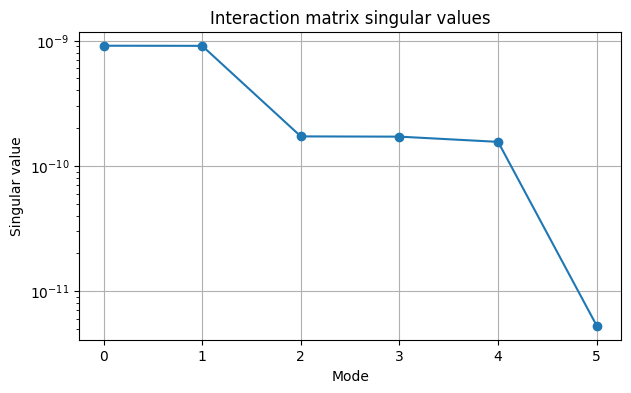

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(
    singular_values.cpu(),
    "o-",
)

plt.yscale("log")
plt.xlabel("Mode")
plt.ylabel("Singular value")
plt.title("Interaction matrix singular values")
plt.grid()
plt.show()

## Display the response of the first calibrated mode

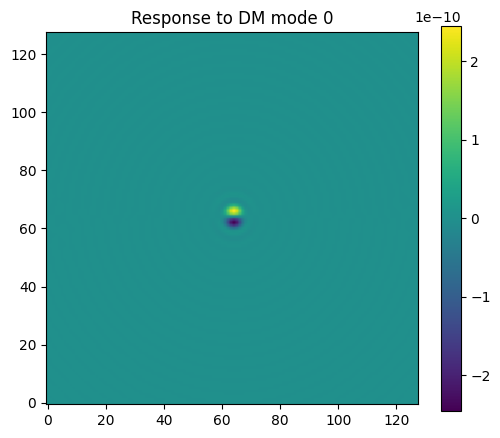

In [9]:
mode = M[:, 0].reshape(
    focal_grid.ny,
    focal_grid.nx,
)

plt.figure(figsize=(6, 5))
plt.imshow(
    mode.cpu(),
    origin="lower",
)

plt.title("Response to DM mode 0")
plt.colorbar()
plt.show()